In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 设置 Matplotlib 中文字体，避免中文标题显示成方框
font_path = "/home/penglei/.local/share/fonts/NotoSansCJKsc-Regular.otf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [18]:
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)
print(iris.feature_names)
print(iris.target_names)

(150, 4)
(150,)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [19]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
svm_model = SVC(kernel="linear")

svm_model.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [23]:
y_pred = svm_model.predict(X_test_scaled)

print("真实结果：", y_test)
print("预测结果：", y_pred)

真实结果： [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
预测结果： [1 0 2 1 1 0 1 2 2 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [24]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


In [25]:
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



In [26]:
kernels = ["linear", "rbf", "poly", "sigmoid"]

for kernel in kernels:
    model = SVC(kernel=kernel)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)

    print(f"kernel={kernel}, 准确率={acc:.4f}")

kernel=linear, 准确率=0.9667
kernel=rbf, 准确率=1.0000
kernel=poly, 准确率=0.9667
kernel=sigmoid, 准确率=0.9000


In [27]:
C_values = [0.1, 1, 10, 100]

for C in C_values:
    model = SVC(kernel="rbf", C=C)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)

    print(f"C={C}, 准确率={acc:.4f}")

C=0.1, 准确率=0.9667
C=1, 准确率=1.0000
C=10, 准确率=0.9667
C=100, 准确率=1.0000


In [28]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

new_flower_scaled = scaler.transform(new_flower)

pred = svm_model.predict(new_flower_scaled)

print("预测类别编号：", pred[0])
print("预测类别名称：", iris.target_names[pred[0]])

预测类别编号： 0
预测类别名称： setosa


In [29]:
X_2d = iris.data[:, [2, 3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_2d,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(kernel="linear")
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("准确率：", accuracy_score(y_test, y_pred))

准确率： 1.0


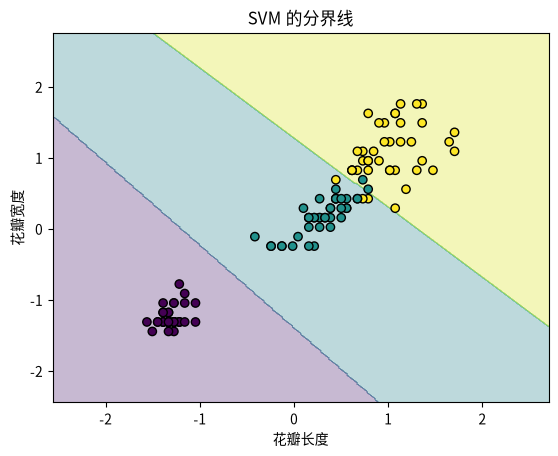

In [30]:
import numpy as np

# 生成一张二维网格，用来覆盖整个散点图区域
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# 把网格上的每一个点都交给 SVM 模型预测
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)

# 把预测结果还原成网格形状
Z = Z.reshape(xx.shape)

# 画分类区域
plt.contourf(xx, yy, Z, alpha=0.3)

# 画训练数据散点
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolors="k"
)

plt.xlabel("花瓣长度")
plt.ylabel("花瓣宽度")
plt.title("SVM 的分界线")
plt.show()

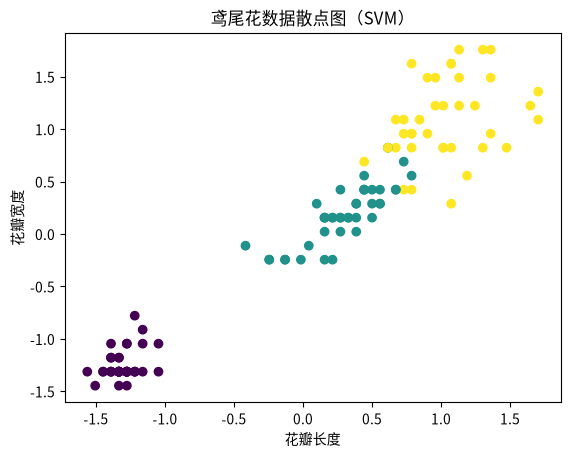

In [31]:
plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train
)

plt.xlabel("花瓣长度")
plt.ylabel("花瓣宽度")
plt.title("鸢尾花数据散点图（SVM）")
plt.show()